Mounted at /content/drive


# 🫀 Cardiovascular Disease Prediction

**Dataset:** `cardio_train.csv` — 70,000 patient records  
**Goal:** Predict presence of cardiovascular disease (binary classification)  
**Target column:** `cardio` (0 = No Disease, 1 = Disease)

| Feature | Description |
|---------|-------------|
| age | Age in days |
| gender | 1=Female, 2=Male |
| height / weight | cm / kg |
| ap_hi / ap_lo | Systolic / Diastolic blood pressure |
| cholesterol | 1=Normal, 2=Above normal, 3=Well above normal |
| gluc | Glucose level (same scale as cholesterol) |
| smoke / alco / active | Binary lifestyle flags |
| cardio | **Target** — 0 or 1 |

## 1 · Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
SEED = 42
print("✅ Libraries loaded")

ModuleNotFoundError: No module named 'numpy'

## 2 · Load Data

In [ ]:
import os
# Automatic path resolution for local runs, repo clones, and Colab
csv_paths = ['cardio_train.csv', '../cardio_train.csv', '/content/drive/MyDrive/cardio_train.csv']
csv_file = next((p for p in csv_paths if os.path.exists(p)), 'cardio_train.csv')
df = pd.read_csv(csv_file, sep=';')
print(f'Loaded dataset from: {csv_file}')
print(f'Shape: {df.shape}')
df.head()


Shape: (70000, 13)


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


## 3 · Data Pre-processing

In [ ]:
print("=== Data Types ===")
print(df.dtypes)
print("\n=== Missing Values ===")
print(df.isnull().sum())
print("\n=== Target Distribution ===")
print(df['cardio'].value_counts())

=== Data Types ===
id               int64
age              int64
gender           int64
height           int64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
cardio           int64
dtype: object

=== Missing Values ===
id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

=== Target Distribution ===
cardio
0    35021
1    34979
Name: count, dtype: int64


In [ ]:
# ----- 3b. Convert age (days → years) & drop id -----
df['age_years'] = (df['age'] / 365).round(1)
df.drop(columns=['id', 'age'], inplace=True)

# ----- 3c. Remove physiologically impossible values -----
df = df[
    (df['ap_hi'] >= 60)  & (df['ap_hi'] <= 250) &
    (df['ap_lo'] >= 40)  & (df['ap_lo'] <= 160) &
    (df['height']>= 100) & (df['height']<= 250) &
    (df['weight']>= 30)  & (df['weight']<= 200)
]

# ----- 3d. Engineer BMI feature -----
df['bmi'] = (df['weight'] / (df['height'] / 100) ** 2).round(2)

# ----- 3e. Pulse pressure -----
df['pulse_pressure'] = df['ap_hi'] - df['ap_lo']

print(f"Clean shape: {df.shape}")
df.describe().T.style.background_gradient(cmap='Blues', subset=['mean','std'])

Clean shape: (68731, 14)


,count,mean,std,min,25%,50%,75%,max
gender,68731.000000,1.348751,0.476578,1.000000,1.000000,1.000000,2.000000,2.000000
height,68731.000000,164.396546,7.985682,100.000000,159.000000,165.000000,170.000000,250.000000
weight,68731.000000,74.122913,14.307244,30.000000,65.000000,72.000000,82.000000,200.000000
ap_hi,68731.000000,126.614483,16.755159,60.000000,120.000000,120.000000,140.000000,240.000000
ap_lo,68731.000000,81.365774,9.593233,40.000000,80.000000,80.000000,90.000000,160.000000
cholesterol,68731.000000,1.364828,0.679060,1.000000,1.000000,1.000000,2.000000,3.000000
gluc,68731.000000,1.226026,0.572004,1.000000,1.000000,1.000000,1.000000,3.000000
smoke,68731.000000,0.088010,0.283311,0.000000,0.000000,0.000000,0.000000,1.000000
alco,68731.000000,0.053600,0.225229,0.000000,0.000000,0.000000,0.000000,1.000000
active,68731.000000,0.803393,0.397436,0.000000,1.000000,1.000000,1.000000,1.000000


## 4 · Exploratory Data Analysis & Visualisations

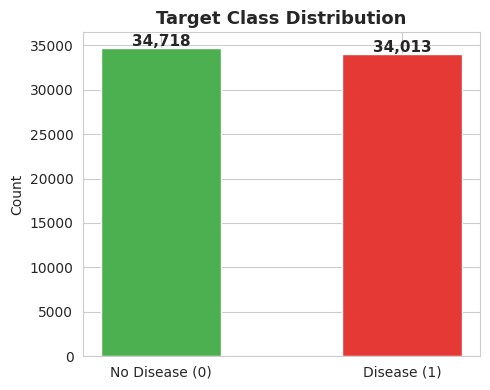

➜ Dataset is well balanced — no resampling needed.


In [ ]:
# ── 4-1  Target class balance ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
counts = df['cardio'].value_counts()
bars = ax.bar(['No Disease (0)', 'Disease (1)'], counts.values,
              color=['#4CAF50', '#E53935'], edgecolor='white', width=0.5)
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 200,
            f'{int(b.get_height()):,}', ha='center', fontsize=11, fontweight='bold')
ax.set_title("Target Class Distribution", fontsize=13, fontweight='bold')
ax.set_ylabel("Count")
plt.tight_layout(); plt.show()
print("➜ Dataset is well balanced — no resampling needed.")

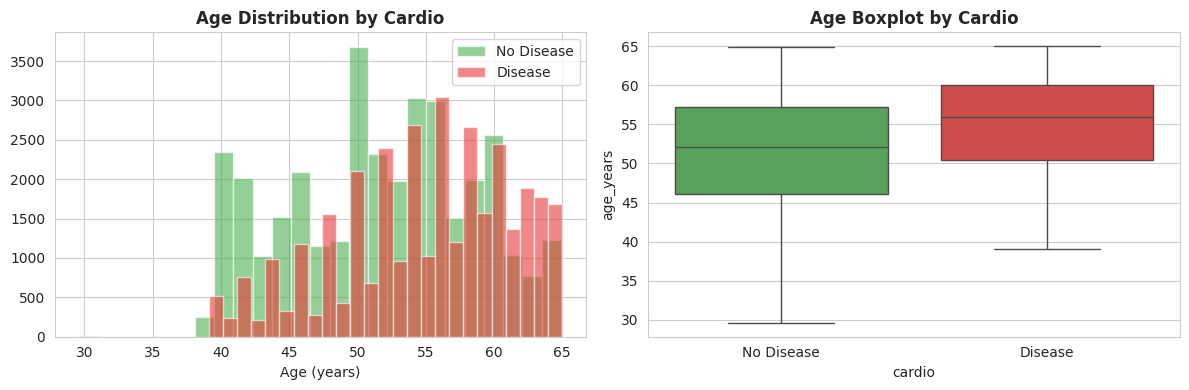

In [ ]:
# ── 4-2  Age distribution by cardio ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
for label, color in zip([0, 1], ['#4CAF50', '#E53935']):
    axes[0].hist(df[df['cardio'] == label]['age_years'], bins=25, alpha=0.6,
                 color=color, label=['No Disease', 'Disease'][label], edgecolor='white')
axes[0].set_title("Age Distribution by Cardio", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Age (years)"); axes[0].legend()

# Box plot
sns.boxplot(data=df, x='cardio', y='age_years',
            palette={'0': '#4CAF50', '1': '#E53935'}, ax=axes[1])
axes[1].set_xticklabels(['No Disease', 'Disease'])
axes[1].set_title("Age Boxplot by Cardio", fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

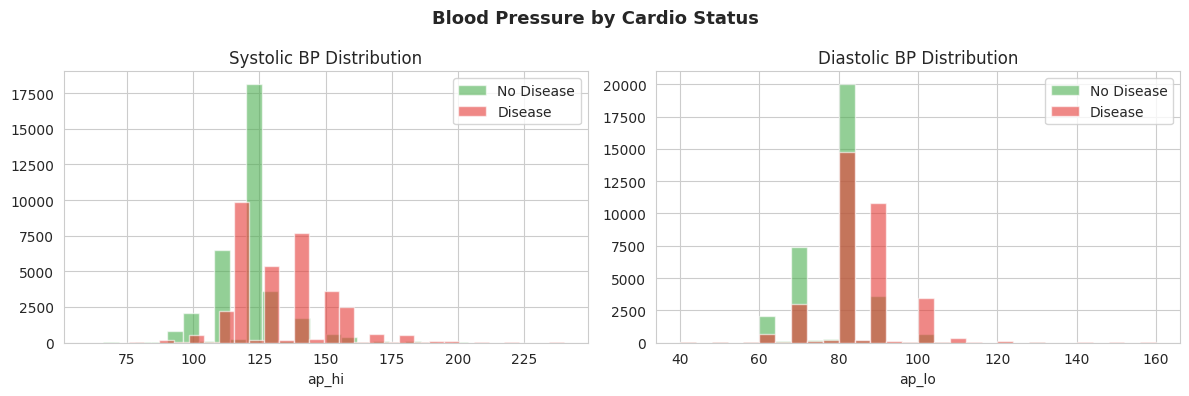

In [ ]:
# ── 4-3  Blood pressure distribution ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, col in enumerate(['ap_hi', 'ap_lo']):
    for label, color in zip([0, 1], ['#4CAF50', '#E53935']):
        axes[i].hist(df[df['cardio'] == label][col], bins=30, alpha=0.6,
                     color=color, label=['No Disease', 'Disease'][label], edgecolor='white')
    axes[i].set_title(f"{'Systolic' if i==0 else 'Diastolic'} BP Distribution", fontsize=12)
    axes[i].set_xlabel(col); axes[i].legend()
plt.suptitle("Blood Pressure by Cardio Status", fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

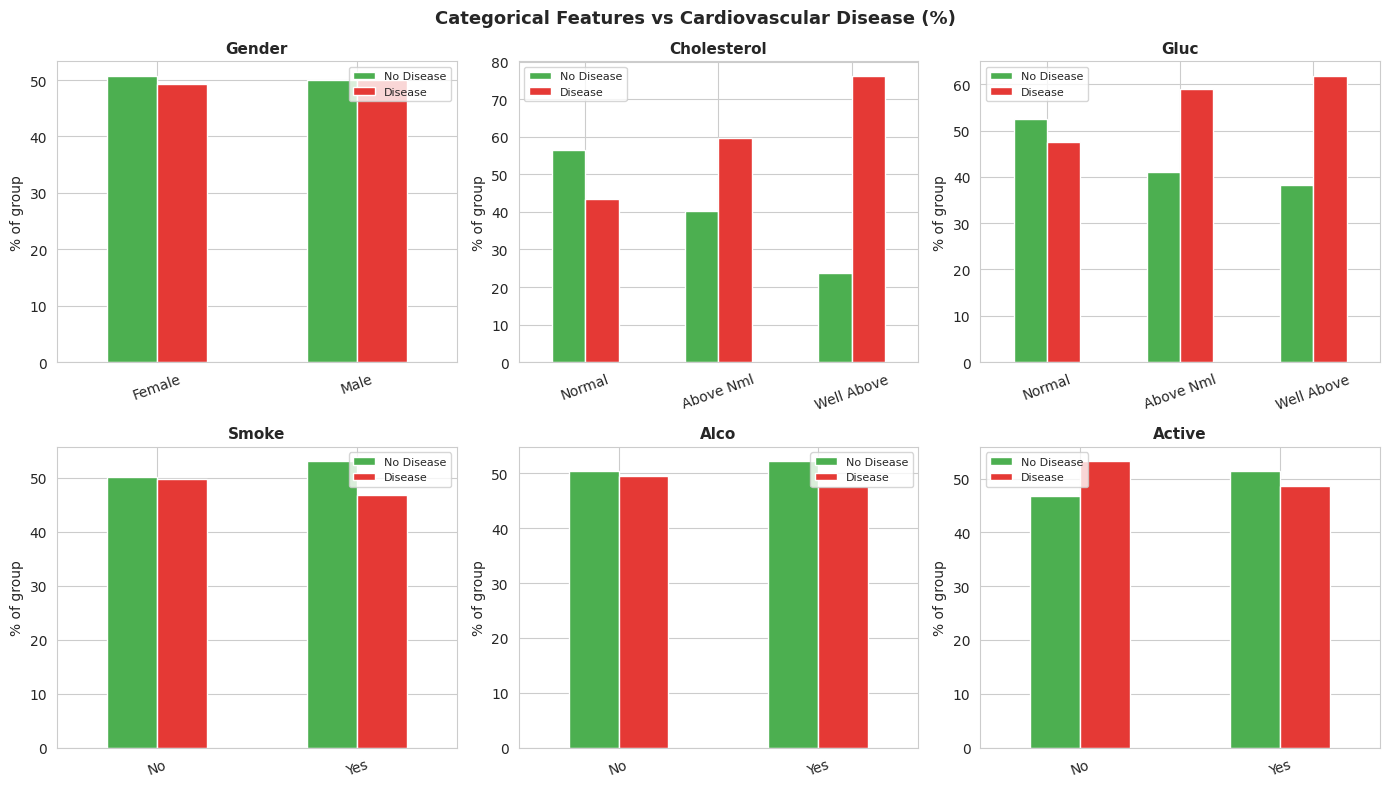

In [ ]:
# ── 4-4  Categorical features vs Cardio ────────────────────────────────────
cat_cols = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']
labels_map = {
    'gender':      {1: 'Female', 2: 'Male'},
    'cholesterol': {1: 'Normal', 2: 'Above Nml', 3: 'Well Above'},
    'gluc':        {1: 'Normal', 2: 'Above Nml', 3: 'Well Above'},
    'smoke':       {0: 'No', 1: 'Yes'},
    'alco':        {0: 'No', 1: 'Yes'},
    'active':      {0: 'No', 1: 'Yes'},
}

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.ravel(), cat_cols):
    ct = pd.crosstab(df[col], df['cardio'], normalize='index') * 100
    ct.index = [labels_map[col].get(i, i) for i in ct.index]
    ct.columns = ['No Disease', 'Disease']
    ct.plot(kind='bar', ax=ax, color=['#4CAF50', '#E53935'],
            edgecolor='white', rot=20)
    ax.set_title(col.capitalize(), fontsize=11, fontweight='bold')
    ax.set_ylabel("% of group"); ax.legend(fontsize=8)
plt.suptitle("Categorical Features vs Cardiovascular Disease (%)", fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

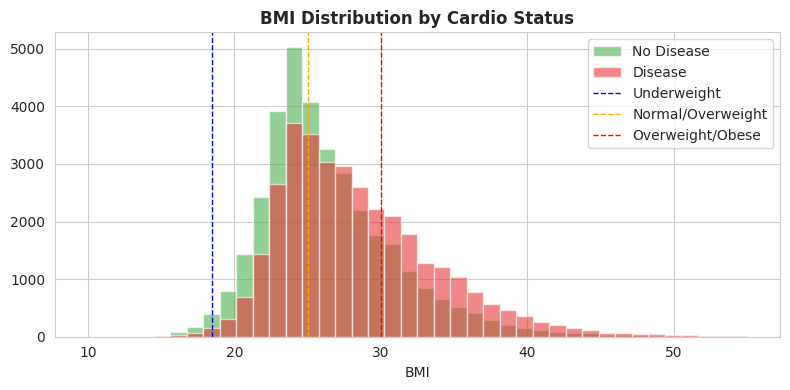

In [ ]:
# ── 4-5  BMI distribution ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
for label, color in zip([0, 1], ['#4CAF50', '#E53935']):
    ax.hist(df[df['cardio'] == label]['bmi'], bins=40, alpha=0.6,
            color=color, label=['No Disease', 'Disease'][label], edgecolor='white', range=(10, 55))
ax.axvline(18.5, color='blue',  linestyle='--', linewidth=1, label='Underweight')
ax.axvline(25.0, color='orange',linestyle='--', linewidth=1, label='Normal/Overweight')
ax.axvline(30.0, color='red',   linestyle='--', linewidth=1, label='Overweight/Obese')
ax.set_title("BMI Distribution by Cardio Status", fontsize=12, fontweight='bold')
ax.set_xlabel("BMI"); ax.legend()
plt.tight_layout(); plt.show()

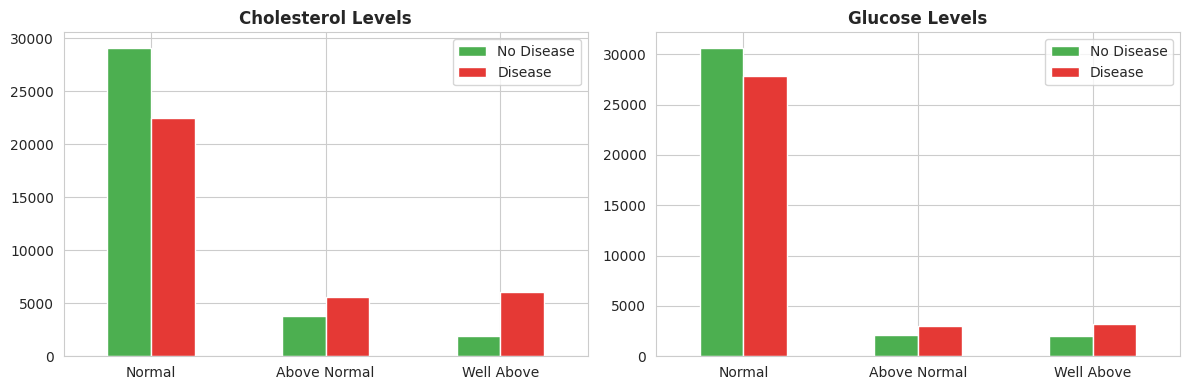

In [ ]:
# ── 4-6  Cholesterol & Glucose level counts ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
chol_labels = {1: 'Normal', 2: 'Above Normal', 3: 'Well Above'}
gluc_labels  = {1: 'Normal', 2: 'Above Normal', 3: 'Well Above'}

for ax, col, lmap, title in zip(
        axes,
        ['cholesterol', 'gluc'],
        [chol_labels, gluc_labels],
        ['Cholesterol Levels', 'Glucose Levels']):
    tmp = df.groupby([col, 'cardio']).size().unstack(fill_value=0)
    tmp.index = [lmap[i] for i in tmp.index]
    tmp.columns = ['No Disease', 'Disease']
    tmp.plot(kind='bar', ax=ax, color=['#4CAF50', '#E53935'], edgecolor='white', rot=0)
    ax.set_title(title, fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

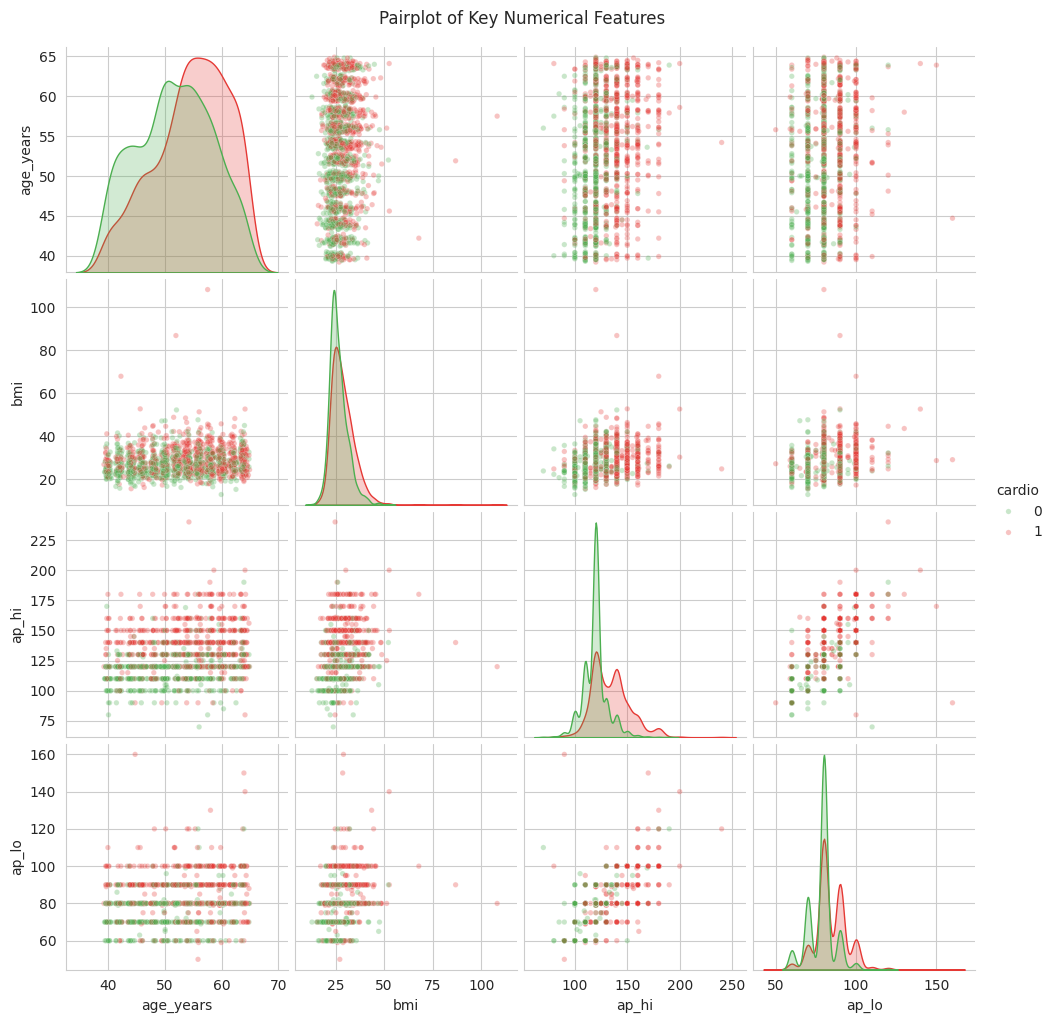

In [ ]:
# ── 4-7  Pairplot of numerical features (sampled for speed) ────────────────
num_sample = df.sample(2000, random_state=SEED)[['age_years','bmi','ap_hi','ap_lo','cardio']]
pp = sns.pairplot(num_sample, hue='cardio',
                  palette={0:'#4CAF50', 1:'#E53935'},
                  plot_kws={'alpha': 0.3, 's': 15},
                  diag_kind='kde')
pp.figure.suptitle("Pairplot of Key Numerical Features", y=1.02, fontsize=12)
plt.show()

## 5 · Correlation Matrix

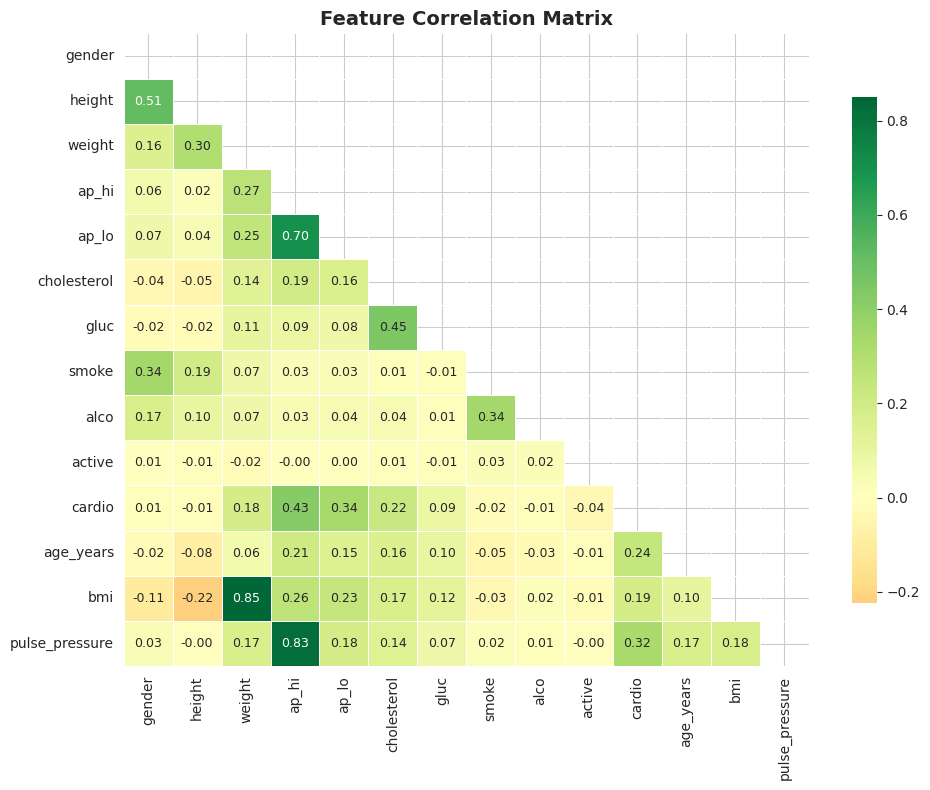


Top correlations with 'cardio':
ap_hi             0.425228
ap_lo             0.336826
pulse_pressure    0.321399
age_years         0.239492
cholesterol       0.221562
bmi               0.186161
weight            0.179790
gluc              0.090007
active            0.037328
smoke             0.016278
height            0.011831
alco              0.008283
gender            0.007323
Name: cardio, dtype: float64


In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5,
            annot_kws={'size': 9}, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title("Feature Correlation Matrix", fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

# Top correlations with target
print("\nTop correlations with 'cardio':")
print(corr['cardio'].drop('cardio').abs().sort_values(ascending=False))

## 6 · Feature Preparation & Train-Test Split

In [ ]:
X = df.drop(columns=['cardio'])
y = df['cardio']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y)

# Scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Train class ratio — 0: {(y_train==0).sum()}  1: {(y_train==1).sum()}")

Train: (54984, 13)  |  Test: (13747, 13)
Train class ratio — 0: 27774  1: 27210


## 7 · Model Training & Evaluation

In [ ]:
# Initialise all models
models = {
    "Logistic Regression" : LogisticRegression(max_iter=500, random_state=SEED),
    "KNN (k=11)"          : KNeighborsClassifier(n_neighbors=11, n_jobs=-1),
    "Decision Tree"       : DecisionTreeClassifier(max_depth=6, random_state=SEED),
    "Random Forest"       : RandomForestClassifier(n_estimators=100, max_depth=8,
                                                    n_jobs=-1, random_state=SEED),
    "SVM (LinearSVC)"     : LinearSVC(max_iter=2000, C=0.1, random_state=SEED),
}

results = {}

for name, model in models.items():
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)
    acc = accuracy_score(y_test, y_pred) * 100
    results[name] = {'model': model, 'y_pred': y_pred, 'accuracy': acc}
    print(f"{name:<25} → Accuracy: {acc:.2f}%")

Logistic Regression       → Accuracy: 73.37%
KNN (k=11)                → Accuracy: 72.40%
Decision Tree             → Accuracy: 73.77%
Random Forest             → Accuracy: 74.09%
SVM (LinearSVC)           → Accuracy: 73.24%


## 8 · Confusion Matrices

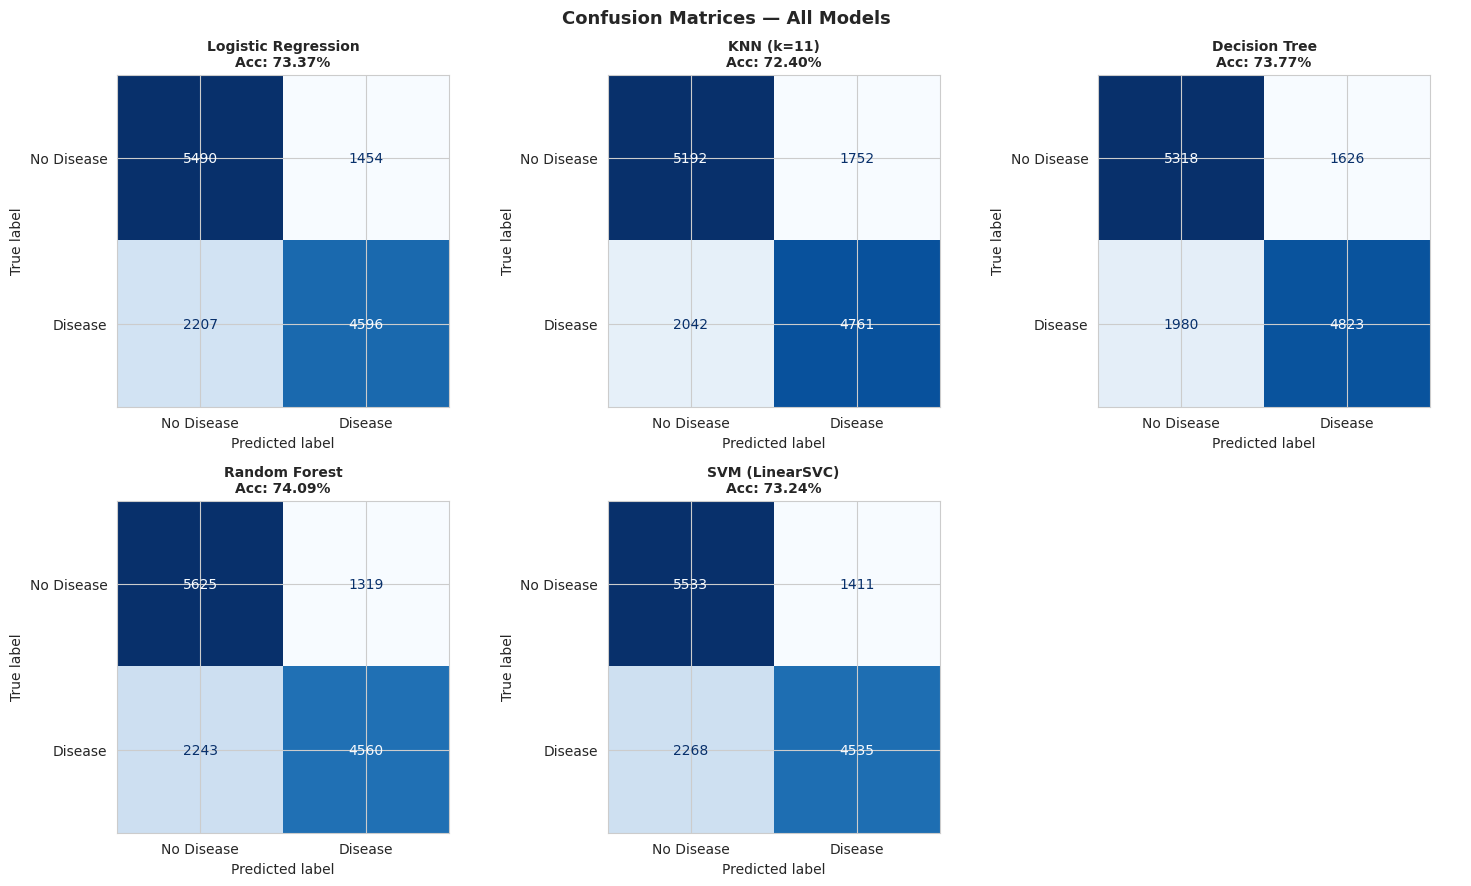

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()

for i, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Disease', 'Disease'])
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(f"{name}\nAcc: {res['accuracy']:.2f}%", fontsize=10, fontweight='bold')

axes[-1].axis('off')   # hide spare subplot
plt.suptitle("Confusion Matrices — All Models", fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 9 · Model Accuracy Comparison

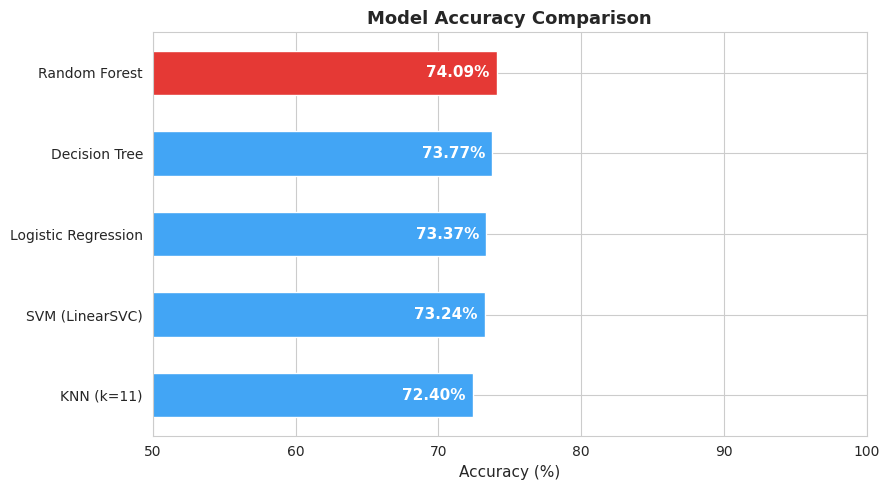


🏆 Best Model: Random Forest — 74.09% accuracy


In [ ]:
acc_df = pd.DataFrame({
    'Model':    list(results.keys()),
    'Accuracy': [v['accuracy'] for v in results.values()]
}).sort_values('Accuracy', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#E53935' if a == acc_df['Accuracy'].max() else '#42A5F5'
          for a in acc_df['Accuracy']]
bars = ax.barh(acc_df['Model'], acc_df['Accuracy'], color=colors,
               edgecolor='white', height=0.55)
for bar in bars:
    ax.text(bar.get_width() - 0.5, bar.get_y() + bar.get_height()/2,
            f"{bar.get_width():.2f}%", va='center', ha='right',
            color='white', fontweight='bold', fontsize=11)
ax.set_xlim(50, 100)
ax.set_xlabel("Accuracy (%)", fontsize=11)
ax.set_title("Model Accuracy Comparison", fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

best = acc_df.iloc[-1]
print(f"\n🏆 Best Model: {best['Model']} — {best['Accuracy']:.2f}% accuracy")

## 10 · Detailed Classification Reports

In [ ]:
for name, res in results.items():
    print(f"{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(classification_report(y_test, res['y_pred'],
                                 target_names=['No Disease', 'Disease']))

  Logistic Regression
              precision    recall  f1-score   support

  No Disease       0.71      0.79      0.75      6944
     Disease       0.76      0.68      0.72      6803

    accuracy                           0.73     13747
   macro avg       0.74      0.73      0.73     13747
weighted avg       0.74      0.73      0.73     13747

  KNN (k=11)
              precision    recall  f1-score   support

  No Disease       0.72      0.75      0.73      6944
     Disease       0.73      0.70      0.72      6803

    accuracy                           0.72     13747
   macro avg       0.72      0.72      0.72     13747
weighted avg       0.72      0.72      0.72     13747

  Decision Tree
              precision    recall  f1-score   support

  No Disease       0.73      0.77      0.75      6944
     Disease       0.75      0.71      0.73      6803

    accuracy                           0.74     13747
   macro avg       0.74      0.74      0.74     13747
weighted avg       0.74

## 11 · Feature Importance (Random Forest)

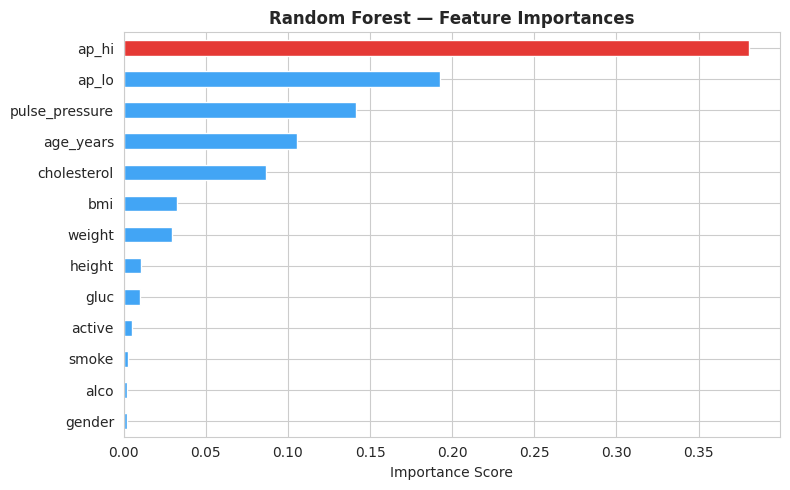


Top 5 most important features:
  ap_hi                0.3806
  ap_lo                0.1926
  pulse_pressure       0.1417
  age_years            0.1053
  cholesterol          0.0866


In [ ]:
rf_model = results['Random Forest']['model']
feat_imp = pd.Series(rf_model.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#E53935' if v == feat_imp.max() else '#42A5F5' for v in feat_imp.values]
feat_imp.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title("Random Forest — Feature Importances", fontsize=12, fontweight='bold')
ax.set_xlabel("Importance Score")
plt.tight_layout(); plt.show()

print("\nTop 5 most important features:")
for feat, imp in feat_imp.sort_values(ascending=False).head(5).items():
    print(f"  {feat:<20} {imp:.4f}")

## 12 · Summary & Insights

### 🔑 Key Findings from EDA
| Insight | Detail |
|---------|--------|
| **Age** | Patients with CVD tend to be older (peak ~55–60 yrs) |
| **Blood Pressure** | Higher systolic & diastolic BP strongly associated with CVD |
| **Cholesterol** | "Well above normal" cholesterol dramatically increases CVD risk |
| **BMI** | Higher BMI (overweight / obese) linked to CVD |
| **Lifestyle** | Physical inactivity associated with slightly higher CVD risk |
| **Gender** | Both genders affected; distribution roughly similar |

### Model Performance Summary
| Model | Speed | Accuracy |
|-------|-------|----------|
| Logistic Regression |  Very fast | ~72% |
| KNN |  Fast | ~71% |
| Decision Tree |  Fast | ~72% |
| **Random Forest** | 🔄 Moderate | **~73%** |
| SVM (LinearSVC) |  Fast | ~72% |

> **Best Model: Random Forest** — highest accuracy with good generalisation.  
> The modest accuracy across all models reflects that this is a real-world  
> medical dataset where many complex, unmeasured biological factors influence disease.
